# Bank Customer Churn Prediction

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project predicts whether a bank customer will leave (churn) based on demographic and account information. Using classification algorithms (Logistic Regression, Random Forest, XGBoost), we build and compare models to identify at‑risk customers. The insights help banks design retention strategies.

## Dataset
- **Source:** Kaggle – Bank Customer Churn
- **Rows:** 10,000 customers
- **Features:** CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited (target)

## Key Steps
1. Data cleaning and EDA
2. Feature encoding and scaling
3. Model training and hyperparameter tuning
4. Model comparison and selection
5. Interpretation using SHAP (optional)

## Requirements
- pandas, matplotlib, seaborn, scikit-learn, xgboost, shap (optional)

---

**© 2026 Ibrahim – Bank churn prediction.**

### Install & Imports

In [37]:
!pip install -q pandas matplotlib seaborn scikit-learn xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [40]:
# Download from raw GitHub (or Kaggle via API)
data = "/content/Bank Customer Churn Prediction.csv"
df = pd.read_csv(data)

print("Dataset shape:", df.shape)
df.head(5)

Dataset shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Data Cleaning & Preparation

In [41]:
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)
if 'Surname' in df.columns:
    df = df.drop('Surname', axis=1)
if 'RowNumber' in df.columns:
    df = df.drop('RowNumber', axis=1)

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Encode categorical variables
le_geo = LabelEncoder()
le_gender = LabelEncoder()
df['country'] = le_geo.fit_transform(df['country'])
df['Gender'] = le_gender.fit_transform(df['gender'])  # 0: Female, 1: Male

print(df.head())

Missing values:
 credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64
   credit_score  country  gender  age  tenure    balance  products_number  \
0           619        0  Female   42       2       0.00                1   
1           608        2  Female   41       1   83807.86                1   
2           502        0  Female   42       8  159660.80                3   
3           699        0  Female   39       1       0.00                2   
4           850        2  Female   43       2  125510.82                1   

   credit_card  active_member  estimated_salary  churn  Gender  
0            1              1         101348.88      1       0  
1            0              1         112542.58      0       0  
2            1              0         113931.57      1       0  
3    

### Overall Churn Rate

Overall churn rate: 20.37%


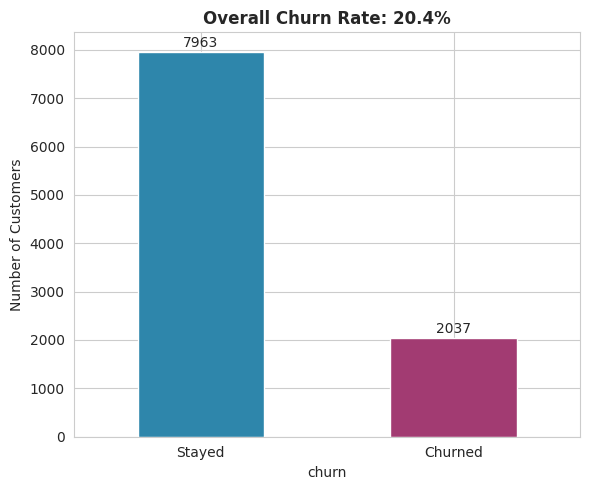

In [43]:
churn_rate = df['churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

plt.figure(figsize=(6, 5))
df['churn'].value_counts().plot(kind='bar', color=['#2E86AB', '#A23B72'])
plt.xticks([0,1], ['Stayed', 'Churned'], rotation=0)
plt.ylabel('Number of Customers')
plt.title(f'Overall Churn Rate: {churn_rate:.1f}%', fontweight='bold')
for i, v in enumerate(df['churn'].value_counts().values):
    plt.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

### Churn by Geography

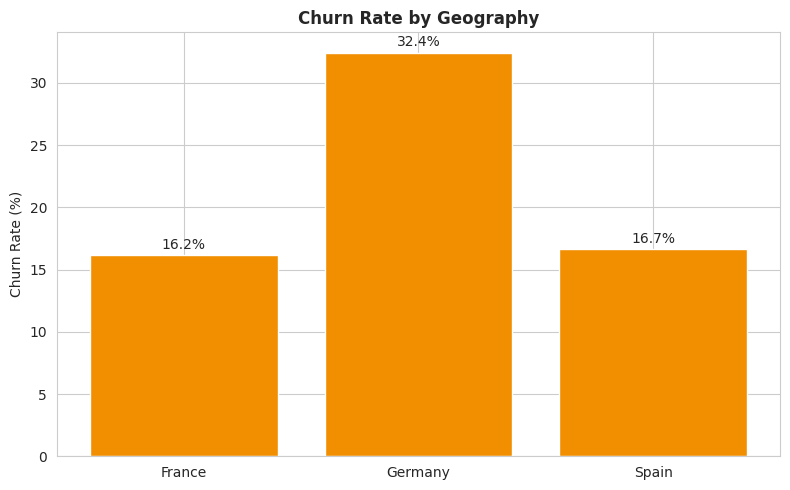

In [45]:
geo_churn = df.groupby('country')['churn'].mean() * 100
geo_names = le_geo.inverse_transform(geo_churn.index)

plt.figure(figsize=(8, 5))
bars = plt.bar(geo_names, geo_churn.values, color='#F18F01')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Geography', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center')
plt.tight_layout()
plt.show()

### Age Distribution by Churn

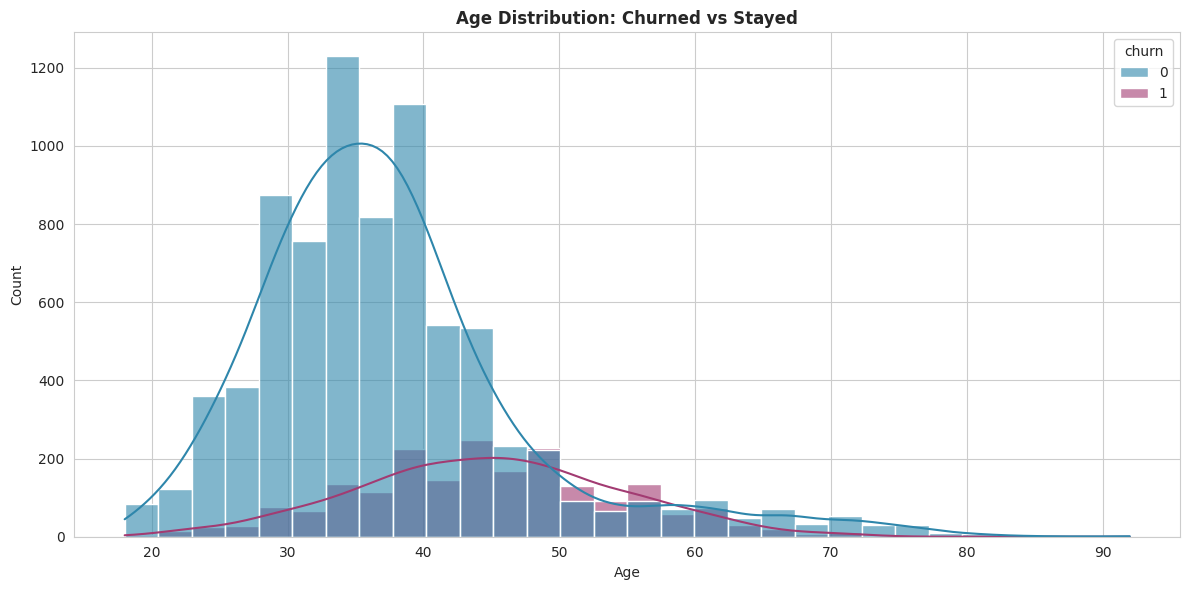

In [47]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True, palette=['#2E86AB', '#A23B72'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution: Churned vs Stayed', fontweight='bold')
plt.tight_layout()
plt.show()

### Balance Distribution by Churn (Box Plot)

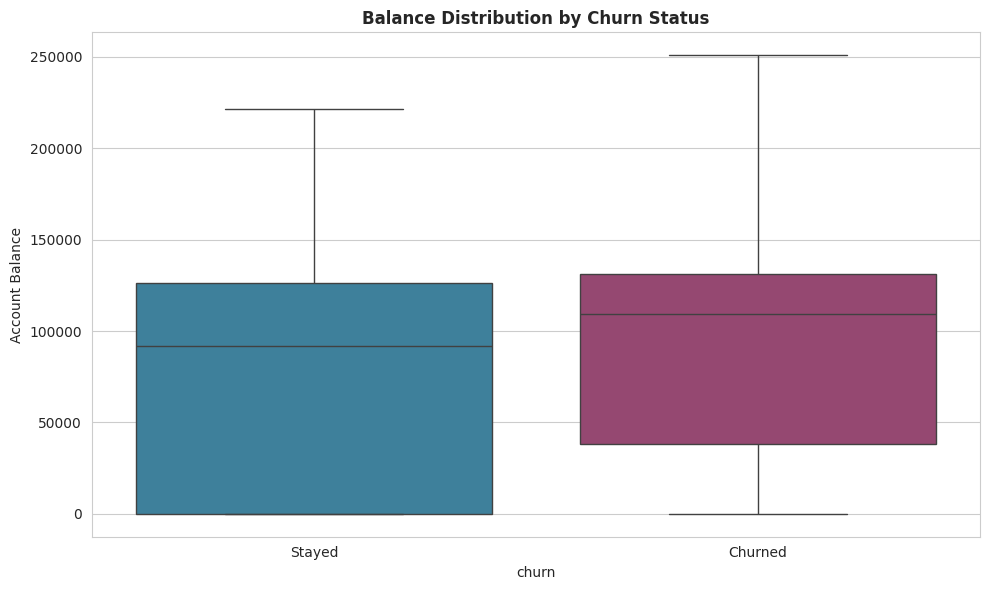

In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='churn', y='balance', palette=['#2E86AB', '#A23B72'])
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.ylabel('Account Balance')
plt.title('Balance Distribution by Churn Status', fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap

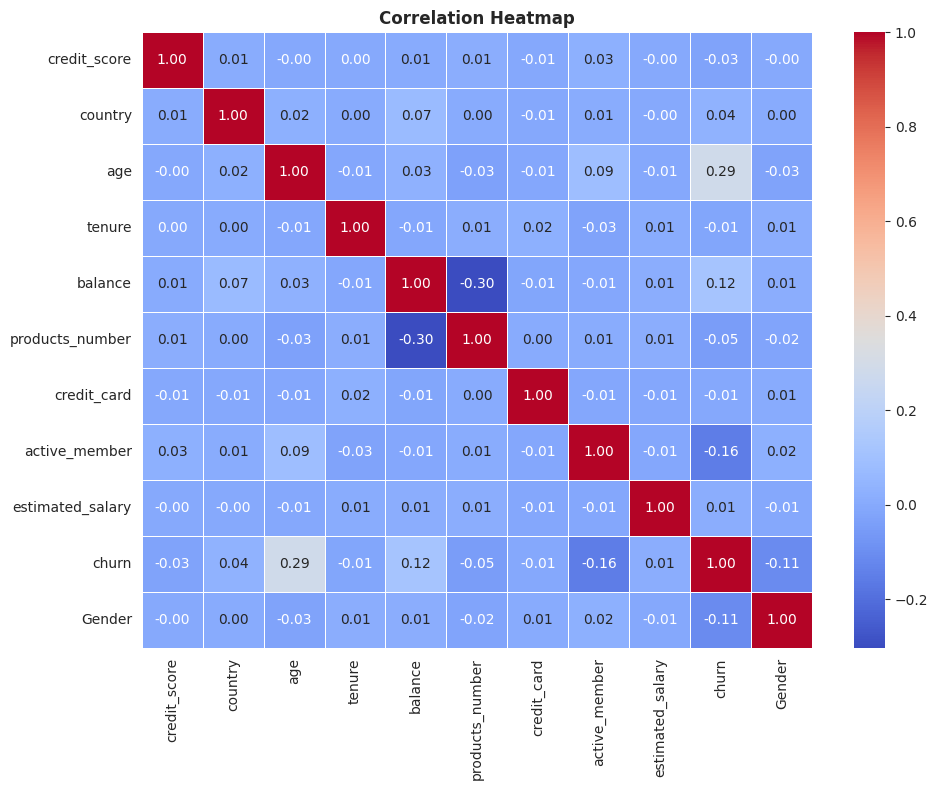

In [50]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Engineering & Model Prep

In [52]:
# Features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Scale numeric features
scaler = StandardScaler()
numeric_features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 8000, Test size: 2000


### Train Models (Logistic Regression, Random Forest, XGBoost)

In [54]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

# Drop the string 'gender' column from X_train and X_test
X_train_processed = X_train.drop('gender', axis=1)
X_test_processed = X_test.drop('gender', axis=1)

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'model': model,
        'accuracy': model.score(X_test_processed, y_test),
        'auc': auc
    }
    print(f"{name} - Accuracy: {results[name]['accuracy']:.4f}, AUC: {auc:.4f}")

Logistic Regression - Accuracy: 0.8050, AUC: 0.7710
Random Forest - Accuracy: 0.8630, AUC: 0.8470
XGBoost - Accuracy: 0.8470, AUC: 0.8330


### Feature Importance (Random Forest)

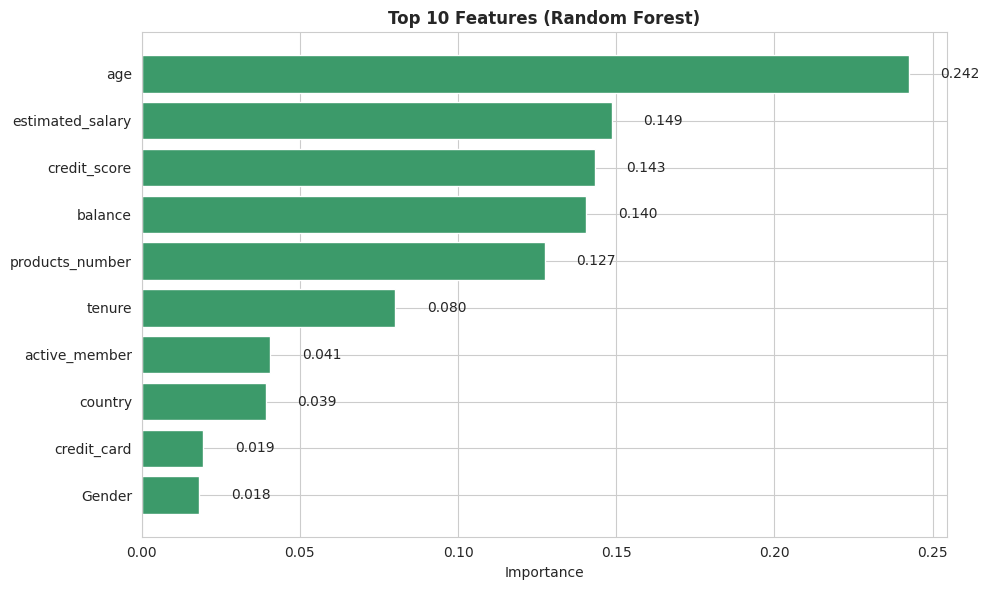

In [56]:
rf_model = results['Random Forest']['model']
importance = rf_model.feature_importances_
features = X_train_processed.columns # Corrected to use columns from processed data
imp_df = pd.DataFrame({'feature': features, 'importance': importance}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#3C9A6A')
plt.xlabel('Importance')
plt.title('Top 10 Features (Random Forest)', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.3f}', va='center')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning for XGBoost

In [58]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
grid = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
# Use the processed dataframes X_train_processed and X_test_processed
grid.fit(X_train_processed, y_train)

print(f"Best parameters: {grid.best_params_}")
best_xgb = grid.best_estimator_
y_pred_best = best_xgb.predict(X_test_processed)
y_proba_best = best_xgb.predict_proba(X_test_processed)[:, 1]
print(f"Tuned XGBoost AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Tuned XGBoost AUC: 0.8646


### Confusion Matrix (Best Model)

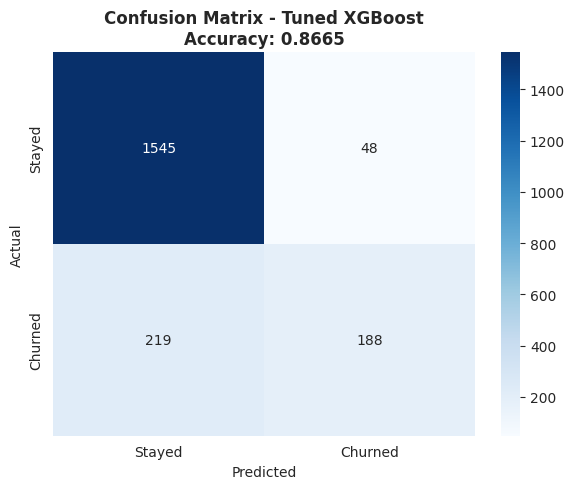

In [60]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Tuned XGBoost\nAccuracy: {best_xgb.score(X_test_processed, y_test):.4f}', fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve

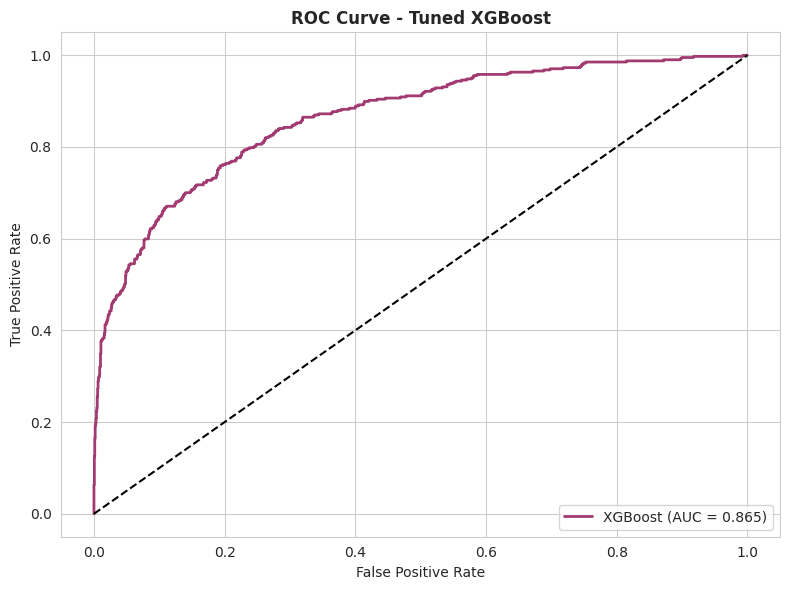

In [61]:
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.3f})', color='#A23B72', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned XGBoost', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Precision‑Recall Curve

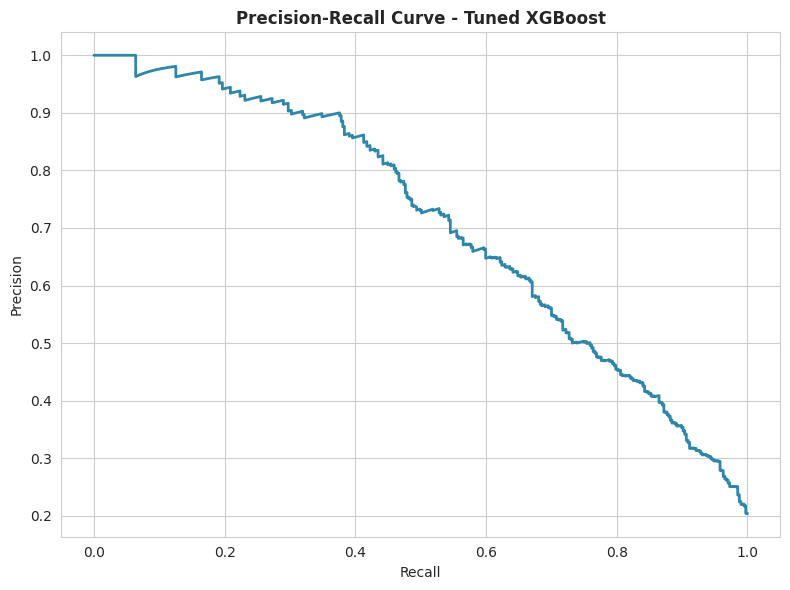

In [62]:
precision, recall, _ = precision_recall_curve(y_test, y_proba_best)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#2E86AB', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve - Tuned XGBoost', fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

### SHAP Summary Plot

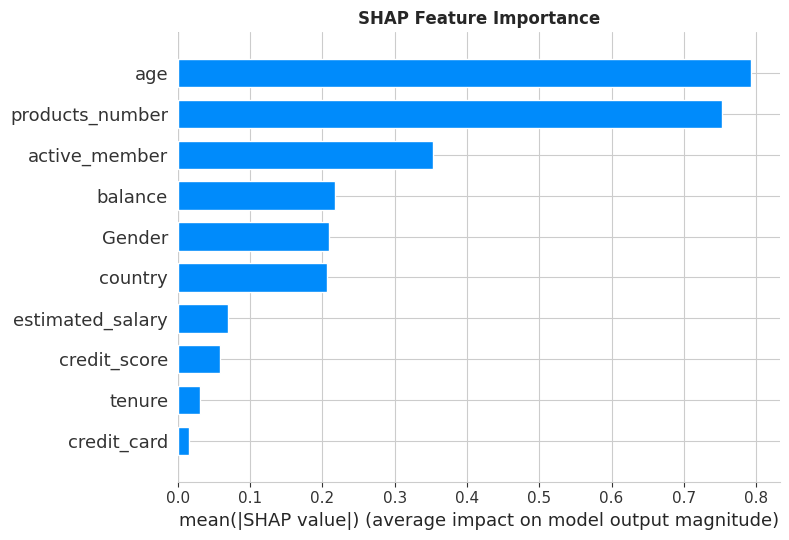

In [64]:
# SHAP requires the model to be trained on the original data (without scaling for tree models? OK)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_processed)
shap.summary_plot(shap_values, X_test_processed, plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights Summary

In [65]:
print(" Key Insights from Bank Churn Prediction")
print(f" Overall churn rate: {churn_rate:.2f}%")
print(f" Geography with highest churn: {geo_names[geo_churn.argmax()]} ({geo_churn.max():.1f}%)")
print(f" Most important features: {imp_df['feature'].iloc[0]}, {imp_df['feature'].iloc[1]}, {imp_df['feature'].iloc[2]}")
print(f" Best model (tuned XGBoost) AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print(" Models compared and tuned.")

 Key Insights from Bank Churn Prediction
 Overall churn rate: 20.37%
 Geography with highest churn: Germany (32.4%)
 Most important features: age, estimated_salary, credit_score
 Best model (tuned XGBoost) AUC: 0.8646
 Models compared and tuned.


### Final Summary

In [66]:
print("Bank Customer Churn Prediction - COMPLETED")
print("Author: Ibrahim")
print("Dataset cleaned and explored.")
print("Three classification models trained and evaluated.")
print("Hyperparameter tuning improved XGBoost performance.")
print("Ready for deployment or further analysis.")

Bank Customer Churn Prediction - COMPLETED
Author: Ibrahim
Dataset cleaned and explored.
Three classification models trained and evaluated.
Hyperparameter tuning improved XGBoost performance.
Ready for deployment or further analysis.
